# Test KNN Clustering with Existing Embeddings

Quick verification of face_cluster library using pre-computed embeddings from benchmark results.

This skips InsightFace detection and uses existing embeddings/crops.

In [1]:
import sys
from pathlib import Path
import numpy as np
from PIL import Image

sys.path.insert(0, str(Path.cwd().parent))

from face_cluster import (
    PipelineConfig,
    FaceRecord,
    KNNGraphBuilder,
    ConnectedComponentsClusterer,
    D10ExemplarSelector,
)
from face_cluster.viz import (
    plot_distance_matrix,
    plot_graph,
    print_cluster_summary,
    show_cluster_faces,
)

print("[OK] Imports complete")

[OK] Imports complete


In [2]:
# Load pre-computed embeddings
RESULTS_DIR = Path("../results/face_clustering_benchmark")
npy_files = sorted(RESULTS_DIR.glob("embeddings_*.npy"), reverse=True)
EMBEDDINGS_FILE = npy_files[0]

embeddings = np.load(EMBEDDINGS_FILE)
print(f"Loaded {embeddings.shape[0]} embeddings from {EMBEDDINGS_FILE.name}")

# Normalize embeddings
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

# Create FaceRecord objects
faces = []
crops_dir = RESULTS_DIR / "face_crops"

for i in range(len(embeddings)):
    # Try to load aligned face crop
    crop_path = crops_dir / f"face_{i:04d}_aligned.jpg"
    if not crop_path.exists():
        crop_path = crops_dir / f"face_{i:04d}.jpg"
    
    aligned_face = None
    if crop_path.exists():
        aligned_face = np.array(Image.open(crop_path))
    
    face = FaceRecord(
        face_id=i,
        image_id=f"img_{i}",
        bbox=(0.0, 0.0, 112.0, 112.0),
        aligned_face=aligned_face,
        embedding=embeddings[i],
        embedding_normalized=embeddings[i],
        pose=(0.0, 0.0, 0.0),  # Unknown
        blur_score=100.0,      # Assume good quality
        area=12544.0,          # 112x112
    )
    faces.append(face)

print(f"[OK] Created {len(faces)} FaceRecord objects")

Loaded 274 embeddings from embeddings_2026-02-20_10-19-23.npy
[OK] Created 274 FaceRecord objects


In [3]:
# Configure clustering (tuned for 274 faces)
config = PipelineConfig(
    K=5,
    distance_threshold=0.35,
    min_cluster_size=2,
    d10_k=3,
    exemplars_d10_threshold=0.35,
    N_exemplars_max=10,
)

print("Configuration:")
print(f"  K={config.K}, threshold={config.distance_threshold}")
print(f"  min_cluster_size={config.min_cluster_size}")

Configuration:
  K=5, threshold=0.35
  min_cluster_size=2


In [4]:
# Build mutual kNN graph
core_indices = list(range(len(faces)))
builder = KNNGraphBuilder(config)

print("Building distance matrix...")
distance_matrix = builder.build_distance_matrix(faces, core_indices)
print(f"  Shape: {distance_matrix.shape}")
print(f"  Min: {distance_matrix.min():.3f}, Max: {distance_matrix.max():.3f}")
print(f"  Mean: {distance_matrix.mean():.3f}, Median: {np.median(distance_matrix):.3f}")

print("\nBuilding mutual kNN graph...")
graph_result = builder.build_graph(faces, core_indices)
print(f"  Nodes: {graph_result.G.number_of_nodes()}")
print(f"  Edges: {graph_result.G.number_of_edges()}")
print(f"  Edge density: {graph_result.G.number_of_edges() / (len(faces) * (len(faces) - 1) / 2):.4%}")

Building distance matrix...
  Shape: (274, 274)
  Min: 0.000, Max: 1.189
  Mean: 0.833, Median: 0.911

Building mutual kNN graph...
  Nodes: 274
  Edges: 234
  Edge density: 0.6257%


In [5]:
# Cluster using connected components
clusterer = ConnectedComponentsClusterer(config)
cluster_result = clusterer.cluster(graph_result, core_indices)

print(f"Clustering complete:")
print(f"  Clusters: {cluster_result.n_clusters}")
print(f"  Noise points: {cluster_result.n_noise}")

print_cluster_summary(cluster_result)

Clustering complete:
  Clusters: 36
  Noise points: 105

Clustering Summary:
  Clusters: 36
  Noise: 105

Cluster  Size   Diameter   Median     P95        Exemplars 
----------------------------------------------------------------------
0        19     0.658      0.395      0.551      0         
23       14     0.704      0.398      0.632      0         
30       12     0.482      0.231      0.390      0         
1        9      0.387      0.256      0.372      0         
10       9      0.361      0.242      0.339      0         
17       9      0.421      0.282      0.387      0         
27       9      0.349      0.213      0.309      0         
9        7      0.353      0.241      0.346      0         
29       7      0.377      0.243      0.297      0         
3        6      0.307      0.190      0.270      0         
21       5      0.406      0.302      0.404      0         
25       5      0.455      0.316      0.448      0         
7        4      0.338      0.296      0.330

In [6]:
# Select exemplars
selector = D10ExemplarSelector(config)
cluster_result = selector.select_exemplars(cluster_result, graph_result)

print("Exemplars selected:")
for cluster_id, exemplar_nodes in sorted(cluster_result.exemplars.items())[:10]:
    exemplar_ids = [faces[core_indices[n]].face_id for n in exemplar_nodes]
    size = len(cluster_result.clusters[cluster_id])
    print(f"  Cluster {cluster_id} (size={size}): {len(exemplar_ids)} exemplars")

No exemplar candidates with d10 <= 0.350, using best face (d10=0.365)


Exemplars selected:
  Cluster 0 (size=19): 10 exemplars
  Cluster 1 (size=9): 5 exemplars
  Cluster 2 (size=3): 1 exemplars
  Cluster 3 (size=6): 2 exemplars
  Cluster 4 (size=2): 2 exemplars
  Cluster 5 (size=2): 1 exemplars
  Cluster 6 (size=2): 2 exemplars
  Cluster 7 (size=4): 3 exemplars
  Cluster 8 (size=2): 2 exemplars
  Cluster 9 (size=7): 4 exemplars


Dataset too large for full graph plot - showing first 100 nodes


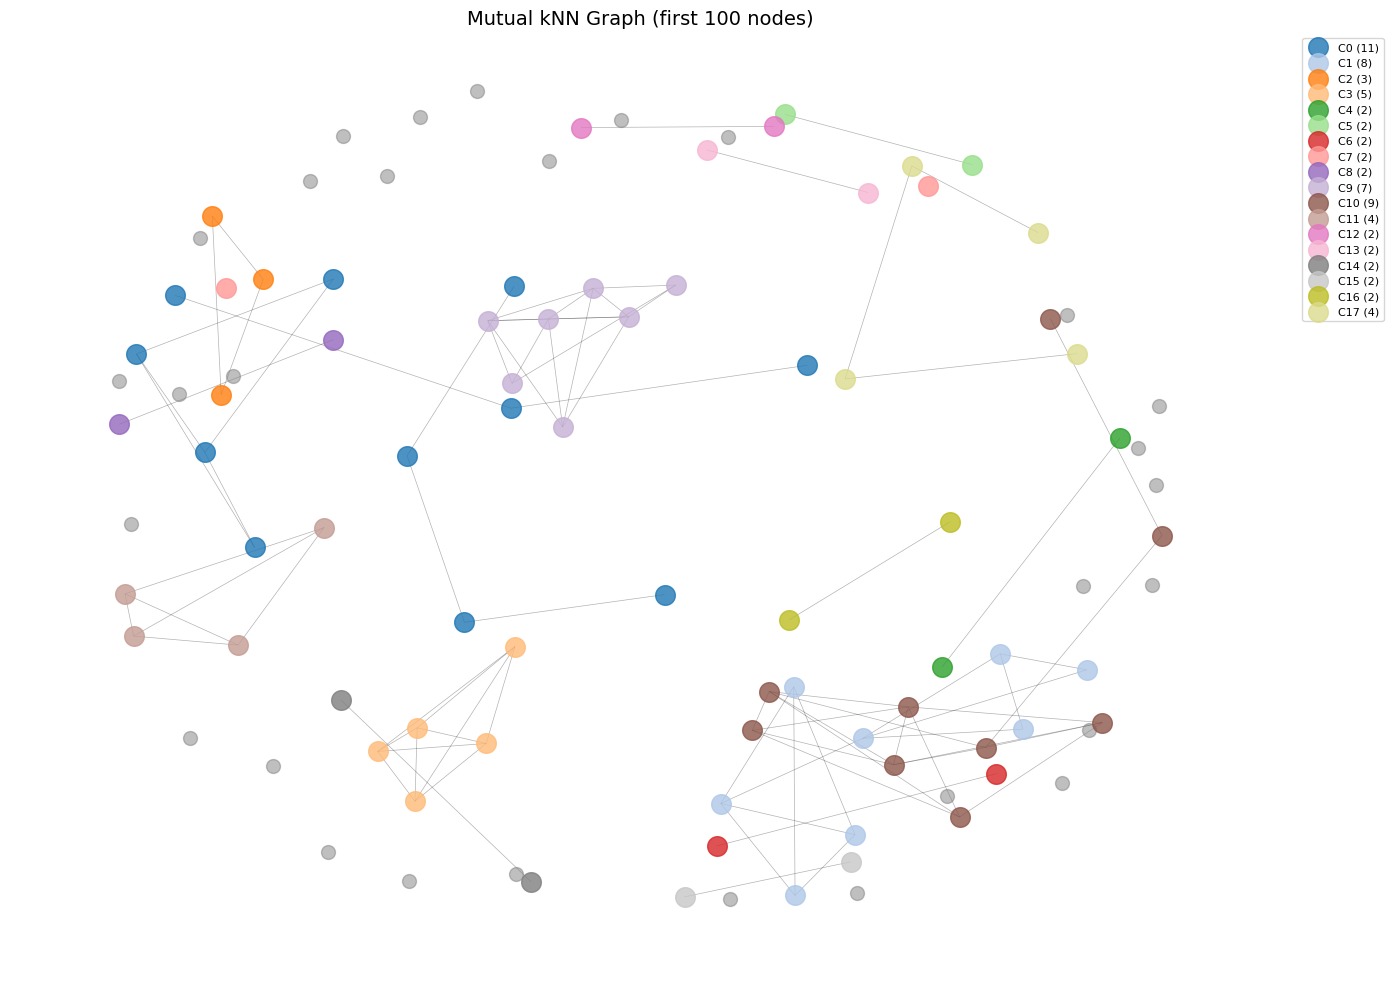

In [7]:
# Visualize graph (sample for large datasets)
if len(faces) <= 100:
    plot_graph(graph_result, cluster_result.labels, title="Mutual kNN Graph")
else:
    # Sample first 100 nodes for visualization
    print("Dataset too large for full graph plot - showing first 100 nodes")
    import networkx as nx
    G_sample = graph_result.G.subgraph(range(min(100, len(faces))))
    from face_cluster.types import GraphResult
    graph_sample = GraphResult(
        neighbors=graph_result.neighbors[:100],
        neighbor_distances=graph_result.neighbor_distances[:100],
        edges=[(u, v, d) for u, v, d in graph_result.edges if u < 100 and v < 100],
        G=G_sample,
        distance_matrix=graph_result.distance_matrix[:100, :100]
    )
    plot_graph(graph_sample, cluster_result.labels[:100], title="Mutual kNN Graph (first 100 nodes)")

Showing first 100 nodes


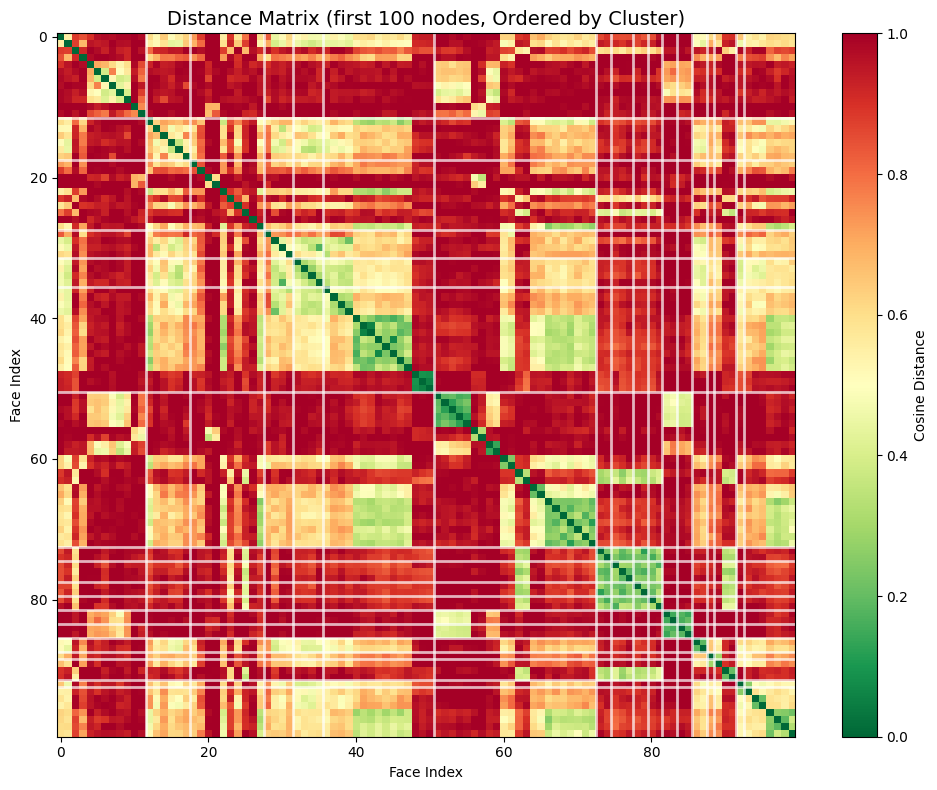

In [8]:
# Plot distance matrix (sample for large datasets)
if len(faces) <= 100:
    plot_distance_matrix(distance_matrix, cluster_result.labels, title="Distance Matrix (Ordered by Cluster)")
else:
    # Sample first 100 nodes
    print("Showing first 100 nodes")
    plot_distance_matrix(
        distance_matrix[:100, :100], 
        cluster_result.labels[:100], 
        title="Distance Matrix (first 100 nodes, Ordered by Cluster)"
    )

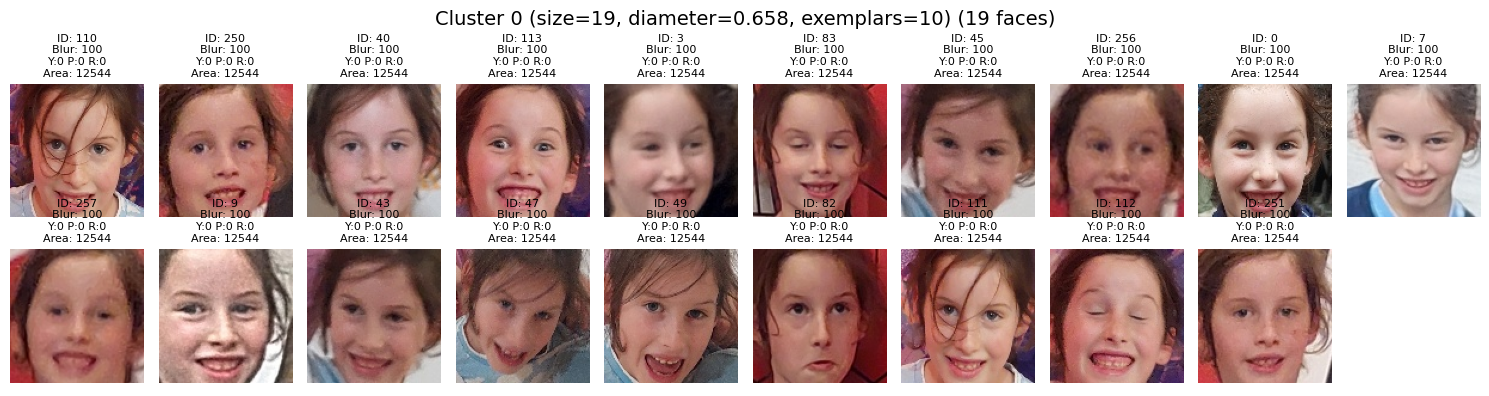

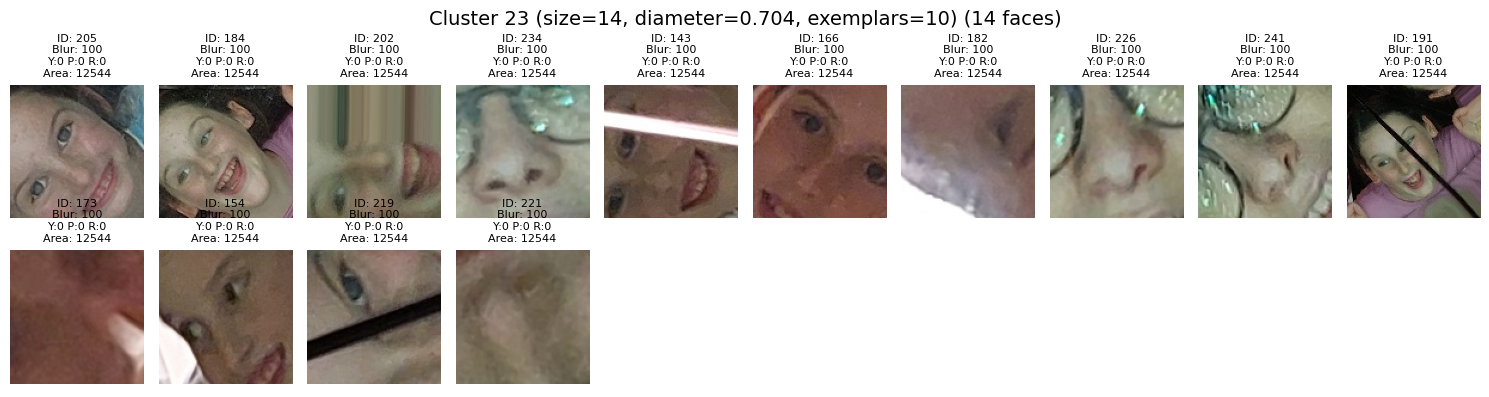

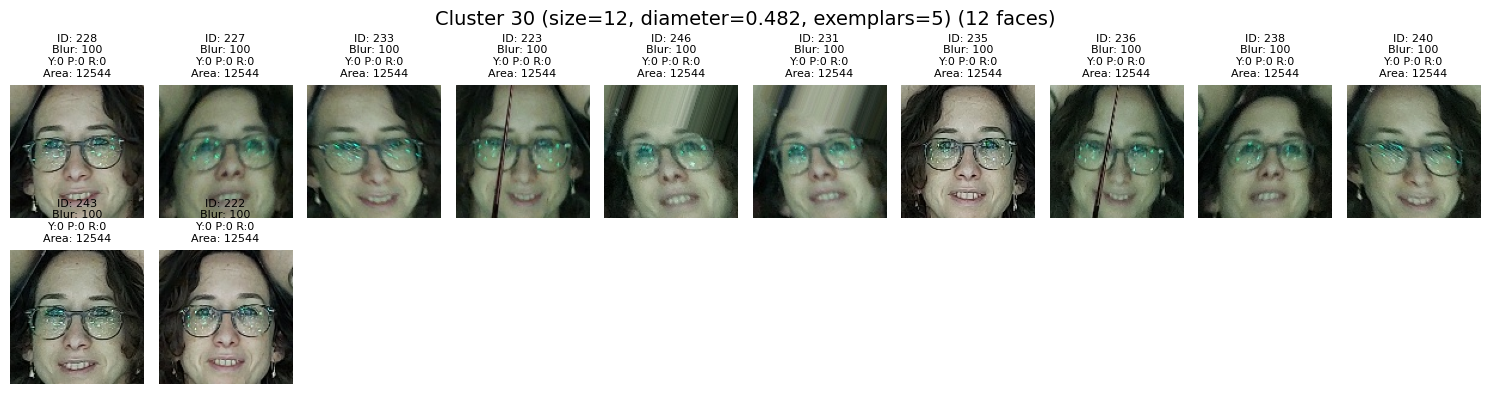

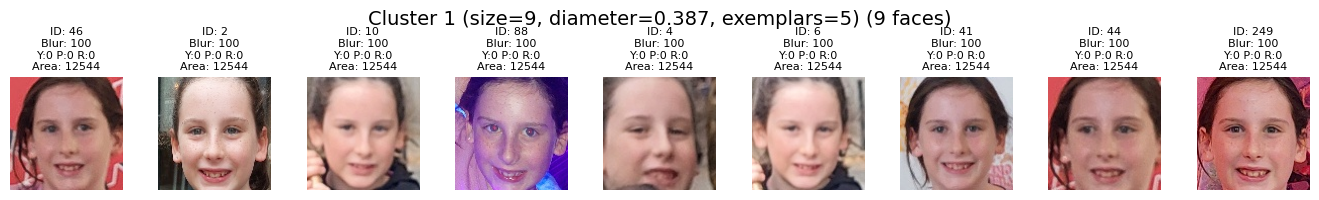

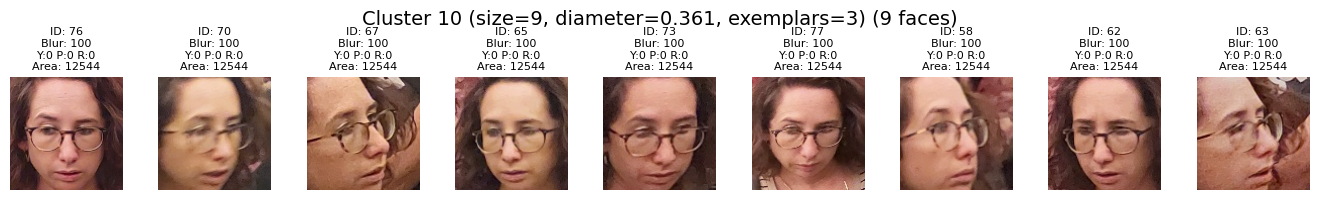

In [9]:
# Show cluster faces (top 5 clusters)
show_cluster_faces(
    faces,
    cluster_result,
    max_clusters=5,
    max_faces_per_cluster=20,
    highlight_exemplars=True
)

In [10]:
print("\n" + "="*60)
print("VERIFICATION COMPLETE")
print("="*60)
print(f"\nProcessed {len(faces)} faces")
print(f"Found {cluster_result.n_clusters} clusters")
print(f"Noise: {cluster_result.n_noise} faces")
print(f"\n[SUCCESS] face_cluster library is working correctly!")


VERIFICATION COMPLETE

Processed 274 faces
Found 36 clusters
Noise: 105 faces

[SUCCESS] face_cluster library is working correctly!
